# Обратная задача: восстановление коэффициента диффузии

$u_t = \partial_x(\alpha\, u_x)$, $x, t \in [0, 1]$, $u(0,t) = u(1,t) = 0$, $u(x,0) = \sin(\pi x)$, истинное $\alpha = 0.46$.

Сеть не знает, что $\alpha$ постоянная, поэтому у неё два выхода: $u = out[:,0]$, $\alpha = out[:,1]$.

$Loss = \lambda_1 L_{PDE} + \lambda_2 L_{BC/IC} + \lambda_3 L_{exp}$, $\lambda_1 = 1$, $\lambda_2 = \lambda_3 = 10$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
import torch
import torch.nn as nn
import tqdm

device = torch.device("cpu")
torch.set_num_threads(8)

ALPHA_TRUE = 0.46

## Данные

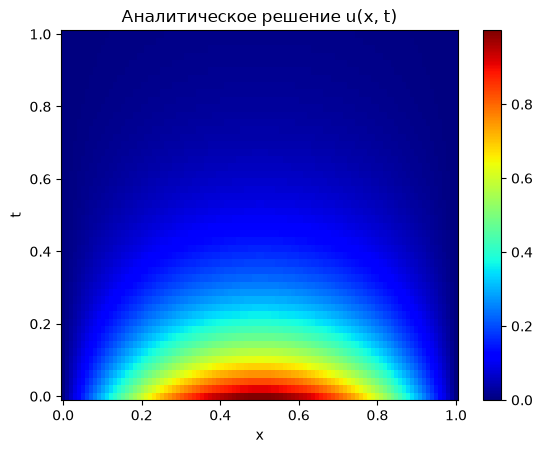

In [2]:
class Dataset:

    def __init__(self, alpha=ALPHA_TRUE, xmin=0, tmin=0, xmax=1, tmax=1,
                 Nx=100, Nt=50, m=1, n=1):
        self.m, self.n, self.alpha = m, n, alpha
        self.Nx, self.Nt = Nx, Nt
        x = np.linspace(xmin, xmax, Nx)
        t = np.linspace(tmin, tmax, Nt)
        self.x, self.t = np.meshgrid(x, t)
        self.solution = analytic(self.x, self.t, alpha, m, n)


def analytic(x, t, alpha=ALPHA_TRUE, m=1, n=1):
    return np.exp(-n**2 * np.pi**2 * alpha * t / m**2) * np.sin(n * np.pi * x / m)


data = Dataset(Nx=100, Nt=50)
plt.pcolormesh(data.x, data.t, data.solution, shading="auto", cmap="jet")
plt.colorbar()
plt.xlabel("x"); plt.ylabel("t")
plt.title("Аналитическое решение u(x, t)")
plt.show()

## Модель

На выход α ставлю softplus, чтобы α > 0. Для сравнения модель `PINNConstAlpha`, где α один обучаемый параметр.

In [3]:
class PINN(nn.Module):

    def __init__(self, input_size=2, nnodes=30, output_size=2, nlayers=6, activation=nn.Tanh):
        super().__init__()
        layers = [nn.Linear(input_size, nnodes), activation()]
        for _ in range(nlayers - 1):
            layers += [nn.Linear(nnodes, nnodes), activation()]
        layers.append(nn.Linear(nnodes, output_size))
        self.net = nn.Sequential(*layers)

    def forward(self, x, t):
        out = self.net(torch.cat([x, t], dim=1))
        u = out[:, 0:1]
        alpha = nn.functional.softplus(out[:, 1:2])
        return u, alpha


class PINNConstAlpha(PINN):

    def __init__(self, alpha_init=0.1, **kw):
        super().__init__(output_size=1, **kw)
        self.log_alpha = nn.Parameter(torch.tensor(float(np.log(alpha_init))))

    def forward(self, x, t):
        u = self.net(torch.cat([x, t], dim=1))
        return u, torch.exp(self.log_alpha).expand_as(u)

## Невязка и loss

In [4]:
def grad(y, x):
    return torch.autograd.grad(y, x, grad_outputs=torch.ones_like(y), create_graph=True)[0]


def PDE(model, x, t):
    u, alpha = model(x, t)
    u_x = grad(u, x)
    u_t = grad(u, t)
    flux_x = grad(alpha * u_x, x)
    return torch.mean((u_t - flux_x) ** 2)


def dataLoss(model, x, t, u_true):
    u_pred, _ = model(x, t)
    return torch.mean((u_pred - u_true) ** 2)


def to_tensor(a):
    return torch.tensor(np.asarray(a).reshape(-1, 1), dtype=torch.float32, device=device)


class TrainParams:
    def __init__(self, dataset, numEpoch=6000, numPoints=1000, numBCPoints=100,
                 lam_pde=1.0, lam_bc=10.0, lam_exp=10.0):
        self.numEpoch, self.numPoints = numEpoch, numPoints
        self.lam_pde, self.lam_bc, self.lam_exp = lam_pde, lam_bc, lam_exp
        self.x_exp, self.t_exp, self.u_exp = map(to_tensor, (dataset.x, dataset.t, dataset.solution))
        s = np.linspace(0, 1, numBCPoints)
        self.x_bc = to_tensor(np.concatenate([s, np.zeros_like(s), np.ones_like(s)]))
        self.t_bc = to_tensor(np.concatenate([np.zeros_like(s), s, s]))
        self.u_bc = to_tensor(np.concatenate([np.sin(np.pi * s), np.zeros_like(s), np.zeros_like(s)]))


def total_loss(model, trp):
    x = torch.rand(trp.numPoints, 1, device=device, requires_grad=True)
    t = torch.rand(trp.numPoints, 1, device=device, requires_grad=True)
    lossPDE = PDE(model, x, t)
    lossBC = dataLoss(model, trp.x_bc, trp.t_bc, trp.u_bc)
    lossExp = dataLoss(model, trp.x_exp, trp.t_exp, trp.u_exp)
    loss = trp.lam_pde * lossPDE + trp.lam_bc * lossBC + trp.lam_exp * lossExp
    return loss, (lossPDE.item(), lossBC.item(), lossExp.item())

## Обучение

Adam, lr = 3e-3, LambdaLR: 0.9995^epoch. Каждые 50 эпох сохраняю среднее / min / max α.

In [5]:
X_EVAL, T_EVAL = np.meshgrid(np.linspace(0, 1, 100), np.linspace(0, 1, 50))
x_eval, t_eval = to_tensor(X_EVAL), to_tensor(T_EVAL)


def predict(model):
    with torch.no_grad():
        u, a = model(x_eval, t_eval)
    return u.cpu().numpy().reshape(X_EVAL.shape), a.cpu().numpy().reshape(X_EVAL.shape)


def alpha_rms_error(alpha_map):
    return np.sqrt(np.mean((alpha_map - ALPHA_TRUE) ** 2)) / ALPHA_TRUE * 100


def train(model, trp, lr0=3e-3, gamma=0.9995, verbose=True, desc="Training"):
    opt = torch.optim.Adam(model.parameters(), lr=lr0)
    scheduler = torch.optim.lr_scheduler.LambdaLR(opt, lr_lambda=lambda e: gamma ** e)
    hist = {"loss": [], "pde": [], "bc": [], "exp": [], "lr": [], "epoch_a": [], "a_mean": [], "a_min": [], "a_max": []}
    pbar = tqdm.tqdm(range(trp.numEpoch), desc=desc, disable=not verbose)
    for step in pbar:
        opt.zero_grad()
        loss, (lp, lb, le) = total_loss(model, trp)
        loss.backward()
        opt.step()
        hist["lr"].append(opt.param_groups[0]["lr"])
        scheduler.step()
        for k, v in zip(("loss", "pde", "bc", "exp"), (loss.item(), lp, lb, le)):
            hist[k].append(v)
        if step % 50 == 0 or step == trp.numEpoch - 1:
            _, a = predict(model)
            hist["epoch_a"].append(step)
            hist["a_mean"].append(a.mean()); hist["a_min"].append(a.min()); hist["a_max"].append(a.max())
            pbar.set_description("%s | Loss: %.2e | alpha mean: %.4f" % (desc, loss.item(), a.mean()))
    return hist

## Сетка наблюдений 100x50

In [6]:
torch.manual_seed(0)
dense = Dataset(Nx=100, Nt=50)
trp = TrainParams(dense)
model = PINN().to(device)
t0 = time.time()
hist = train(model, trp, desc="100x50")
print("время обучения: %.0f с" % (time.time() - t0))

u_pred, a_pred = predict(model)
u_true = analytic(X_EVAL, T_EVAL)
print("alpha: среднее = %.4f, min = %.4f, max = %.4f (истина %.2f)" % (a_pred.mean(), a_pred.min(), a_pred.max(), ALPHA_TRUE))
print("СКЗ восстановления alpha = %.2f %%" % alpha_rms_error(a_pred))
print("СКЗ u = %.2e (отн. %.2f %%)" % (np.sqrt(np.mean((u_pred - u_true) ** 2)),
                                     np.sqrt(np.mean((u_pred - u_true) ** 2)) / np.sqrt(np.mean(u_true ** 2)) * 100))

100x50:   0%|          | 0/6000 [00:00<?, ?it/s]

100x50 | Loss: 1.57e+00 | alpha mean: 0.6923:   0%|          | 0/6000 [00:00<?, ?it/s]

100x50 | Loss: 1.57e+00 | alpha mean: 0.6923:   0%|          | 8/6000 [00:00<01:15, 79.50it/s]

100x50 | Loss: 1.57e+00 | alpha mean: 0.6923:   0%|          | 20/6000 [00:00<00:58, 102.24it/s]

100x50 | Loss: 1.57e+00 | alpha mean: 0.6923:   1%|          | 32/6000 [00:00<00:54, 109.62it/s]

...

100x50 | Loss: 1.83e-04 | alpha mean: 0.4674: 100%|█████████▉| 5985/6000 [00:51<00:00, 116.51it/s]

100x50 | Loss: 1.83e-04 | alpha mean: 0.4674: 100%|█████████▉| 5997/6000 [00:51<00:00, 117.11it/s]

100x50 | Loss: 1.87e-04 | alpha mean: 0.4674: 100%|█████████▉| 5997/6000 [00:51<00:00, 117.11it/s]

100x50 | Loss: 1.87e-04 | alpha mean: 0.4674: 100%|██████████| 6000/6000 [00:51<00:00, 116.61it/s]

время обучения: 52 с
alpha: среднее = 0.4674, min = 0.4381, max = 0.4916 (истина 0.46)
СКЗ восстановления alpha = 3.23 %
СКЗ u = 1.53e-03 (отн. 0.63 %)


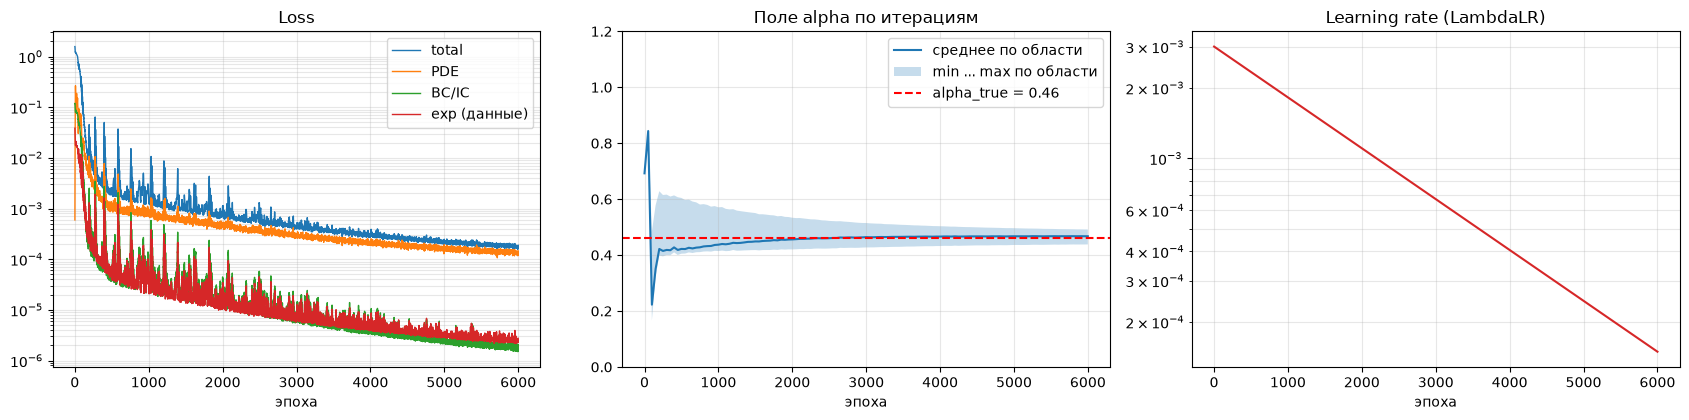

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4.3))
ep = np.arange(1, len(hist["loss"]) + 1)
for k, lab in [("loss", "total"), ("pde", "PDE"), ("bc", "BC/IC"), ("exp", "exp (данные)")]:
    ax[0].semilogy(ep, hist[k], lw=1, label=lab)
ax[0].set_title("Loss"); ax[0].set_xlabel("эпоха"); ax[0].legend(); ax[0].grid(True, which="both", alpha=0.3)

ax[1].plot(hist["epoch_a"], hist["a_mean"], label="среднее по области")
ax[1].fill_between(hist["epoch_a"], hist["a_min"], hist["a_max"], alpha=0.25, label="min ... max по области")
ax[1].axhline(ALPHA_TRUE, color="r", ls="--", label="alpha_true = 0.46")
ax[1].set_ylim(0, 1.2); ax[1].set_title("Поле alpha по итерациям"); ax[1].set_xlabel("эпоха"); ax[1].legend()
ax[1].grid(True, alpha=0.3)

ax[2].plot(ep, hist["lr"], color="tab:red")
ax[2].set_yscale("log"); ax[2].set_title("Learning rate (LambdaLR)"); ax[2].set_xlabel("эпоха")
ax[2].grid(True, which="both", alpha=0.3)
plt.tight_layout(); plt.show()

### Поле α(x, t) и где ошибка

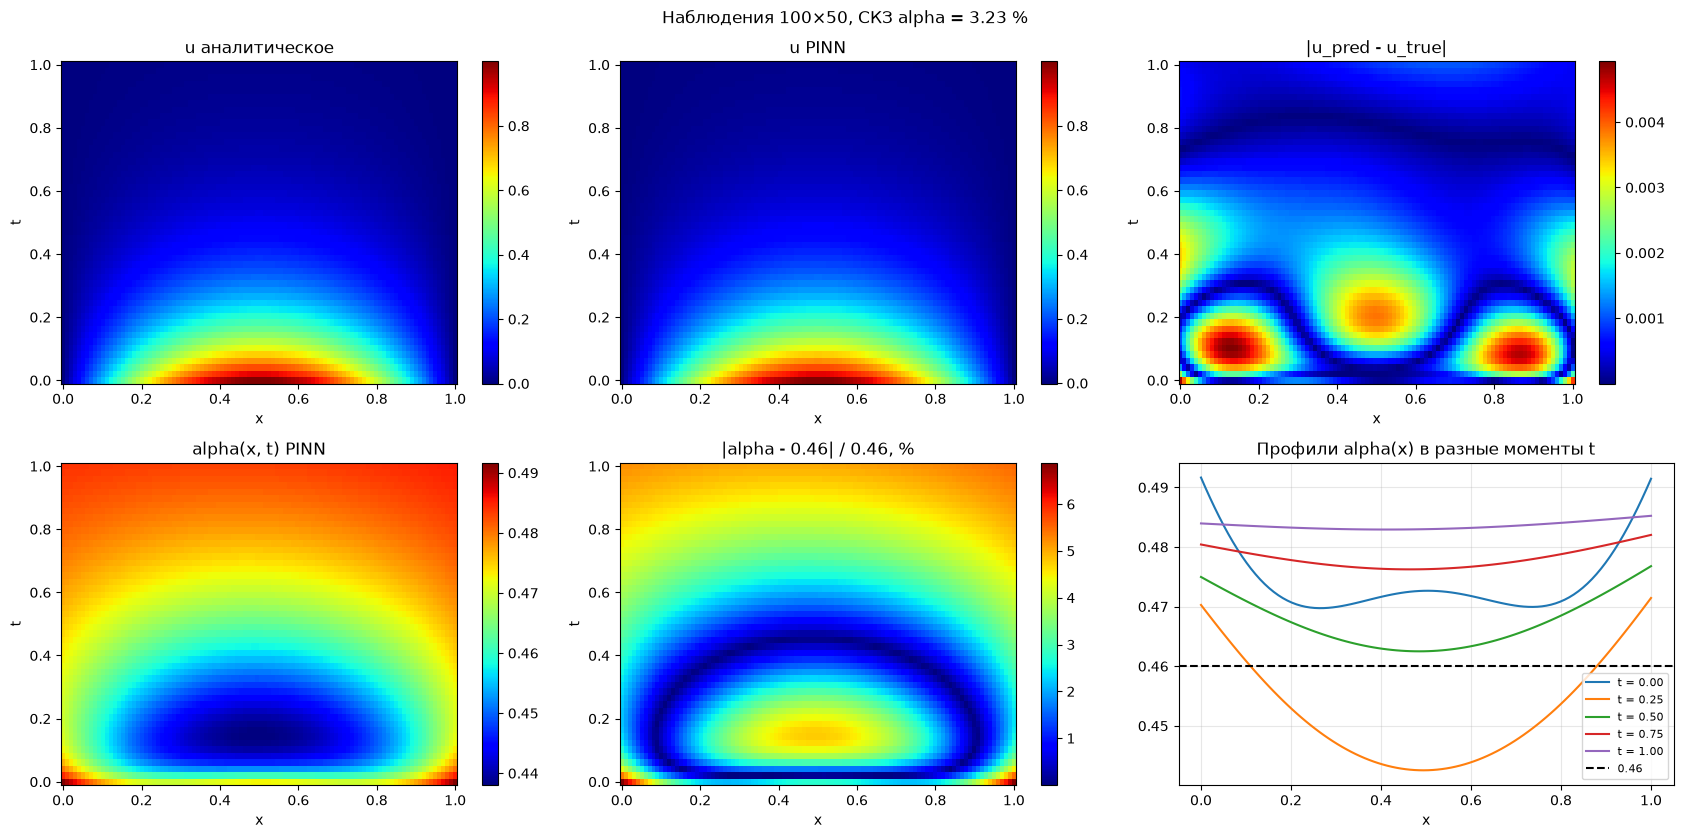

максимальная ошибка alpha: 6.9 % в точке x = 0.00, t = 0.00
СКЗ alpha во внутренней области x, t in (0.1, 0.9): 2.96 %
СКЗ alpha в полосе 0.4 < x < 0.6 (где du/dx ~ 0): 3.29 %


In [8]:
def plot_fields(u_pred, a_pred, title=""):
    fig, ax = plt.subplots(2, 3, figsize=(17, 8.5))
    for a_, f, t_, kw in [(ax[0, 0], u_true, "u аналитическое", {}),
                          (ax[0, 1], u_pred, "u PINN", {}),
                          (ax[0, 2], np.abs(u_pred - u_true), "|u_pred - u_true|", {}),
                          (ax[1, 0], a_pred, "alpha(x, t) PINN", {}),
                          (ax[1, 1], np.abs(a_pred - ALPHA_TRUE) / ALPHA_TRUE * 100, "|alpha - 0.46| / 0.46, %", {})]:
        pcm = a_.pcolormesh(X_EVAL, T_EVAL, f, shading="auto", cmap="jet", **kw)
        fig.colorbar(pcm, ax=a_); a_.set_title(t_); a_.set_xlabel("x"); a_.set_ylabel("t")
    for ti in [0.0, 0.25, 0.5, 0.75, 1.0]:
        j = np.argmin(np.abs(T_EVAL[:, 0] - ti))
        ax[1, 2].plot(X_EVAL[j], a_pred[j], label="t = %.2f" % ti)
    ax[1, 2].axhline(ALPHA_TRUE, color="k", ls="--", label="0.46")
    ax[1, 2].set_title("Профили alpha(x) в разные моменты t"); ax[1, 2].set_xlabel("x")
    ax[1, 2].legend(fontsize=8); ax[1, 2].grid(True, alpha=0.3)
    fig.suptitle(title); plt.tight_layout(); plt.show()


plot_fields(u_pred, a_pred, "Наблюдения 100×50, СКЗ alpha = %.2f %%" % alpha_rms_error(a_pred))

err = np.abs(a_pred - ALPHA_TRUE) / ALPHA_TRUE * 100
i = np.unravel_index(err.argmax(), err.shape)
print("максимальная ошибка alpha: %.1f %% в точке x = %.2f, t = %.2f" % (err.max(), X_EVAL[i], T_EVAL[i]))
inner = (X_EVAL > 0.1) & (X_EVAL < 0.9) & (T_EVAL > 0.1) & (T_EVAL < 0.9)
print("СКЗ alpha во внутренней области x, t in (0.1, 0.9): %.2f %%" %
      (np.sqrt(np.mean((a_pred[inner] - ALPHA_TRUE) ** 2)) / ALPHA_TRUE * 100))
print("СКЗ alpha в полосе 0.4 < x < 0.6 (где du/dx ~ 0): %.2f %%" %
      (np.sqrt(np.mean((a_pred[np.abs(X_EVAL - 0.5) < 0.1] - ALPHA_TRUE) ** 2)) / ALPHA_TRUE * 100))

## Ошибка в зависимости от числа точек

Уменьшаю сетку наблюдений, на каждой учу с нуля. Рядом модель с α = const.

In [9]:
def run_experiment(Nx, Nt, model_cls=PINN, seed=0):
    torch.manual_seed(seed)
    ds = Dataset(Nx=Nx, Nt=Nt)
    model = model_cls().to(device)
    train(model, TrainParams(ds), verbose=False)
    u_p, a_p = predict(model)
    return model, u_p, a_p


grid_sizes = [(100, 50), (50, 25), (20, 10), (10, 5), (6, 3), (5, 3), (4, 2), (3, 2), (2, 2)]

results, maps = [], {}
for Nx, Nt in grid_sizes:
    t0 = time.time()
    _, u_f, a_f = run_experiment(Nx, Nt, PINN)
    _, u_c, a_c = run_experiment(Nx, Nt, PINNConstAlpha)
    maps[(Nx, Nt)] = (u_f, a_f)
    r = dict(Nx=Nx, Nt=Nt, N=Nx * Nt, N_inner=(Nx - 2) * (Nt - 1),
             err_field=alpha_rms_error(a_f), err_max=np.abs(a_f - ALPHA_TRUE).max() / ALPHA_TRUE * 100,
             a_mean=a_f.mean(), err_const=alpha_rms_error(a_c), a_const=a_c[0, 0])
    results.append(r)
    print("Nx=%3d Nt=%2d N=%4d (вне ГУ/НУ: %4d) | alpha(x,t): СКЗ %6.2f %%, max %6.1f %%, среднее %.4f | "
          "alpha=const: %.4f (ошибка %5.2f %%) | %.0f с"
          % (Nx, Nt, r["N"], r["N_inner"], r["err_field"], r["err_max"], r["a_mean"], r["a_const"], r["err_const"], time.time() - t0))

Nx=100 Nt=50 N=5000 (вне ГУ/НУ: 4802) | alpha(x,t): СКЗ   3.23 %, max    6.9 %, среднее 0.4674 | alpha=const: 0.4601 (ошибка  0.03 %) | 101 с


Nx= 50 Nt=25 N=1250 (вне ГУ/НУ: 1152) | alpha(x,t): СКЗ   3.56 %, max    7.0 %, среднее 0.4684 | alpha=const: 0.4602 (ошибка  0.04 %) | 80 с


Nx= 20 Nt=10 N= 200 (вне ГУ/НУ:  162) | alpha(x,t): СКЗ   3.77 %, max    7.8 %, среднее 0.4675 | alpha=const: 0.4602 (ошибка  0.04 %) | 66 с


Nx= 10 Nt= 5 N=  50 (вне ГУ/НУ:   32) | alpha(x,t): СКЗ   2.34 %, max   10.0 %, среднее 0.4577 | alpha=const: 0.4603 (ошибка  0.07 %) | 61 с


Nx=  6 Nt= 3 N=  18 (вне ГУ/НУ:    8) | alpha(x,t): СКЗ   5.42 %, max   18.5 %, среднее 0.4458 | alpha=const: 0.4598 (ошибка  0.05 %) | 60 с


Nx=  5 Nt= 3 N=  15 (вне ГУ/НУ:    6) | alpha(x,t): СКЗ   5.53 %, max   18.7 %, среднее 0.4461 | alpha=const: 0.4598 (ошибка  0.05 %) | 61 с


Nx=  4 Nt= 2 N=   8 (вне ГУ/НУ:    2) | alpha(x,t): СКЗ   7.31 %, max   15.4 %, среднее 0.4384 | alpha=const: 0.4243 (ошибка  7.77 %) | 61 с


Nx=  3 Nt= 2 N=   6 (вне ГУ/НУ:    1) | alpha(x,t): СКЗ   5.30 %, max   10.3 %, среднее 0.4392 | alpha=const: 0.4192 (ошибка  8.88 %) | 61 с


Nx=  2 Nt= 2 N=   4 (вне ГУ/НУ:    0) | alpha(x,t): СКЗ  75.02 %, max   76.0 %, среднее 0.1149 | alpha=const: 0.0751 (ошибка 83.68 %) | 63 с


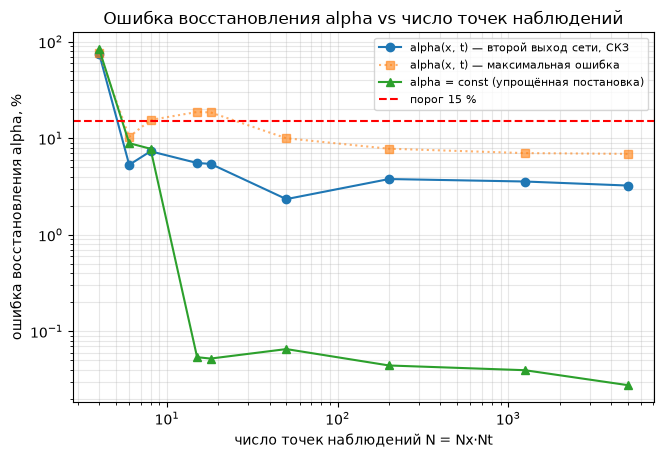

Минимальная сетка с СКЗ alpha <= 15 %: Nx = 3, Nt = 2, N = 6 точек, СКЗ = 5.30 %
из них вне ГУ/НУ (реально информативных): 1


In [10]:
N = np.array([r["N"] for r in results])
fig, ax = plt.subplots(figsize=(7.5, 4.8))
ax.plot(N, [r["err_field"] for r in results], "o-", label="alpha(x, t) — второй выход сети, СКЗ")
ax.plot(N, [r["err_max"] for r in results], "s:", alpha=0.6, label="alpha(x, t) — максимальная ошибка")
ax.plot(N, [r["err_const"] for r in results], "^-", label="alpha = const (упрощённая постановка)")
ax.axhline(15, color="r", ls="--", label="порог 15 %")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("число точек наблюдений N = Nx·Nt"); ax.set_ylabel("ошибка восстановления alpha, %")
ax.set_title("Ошибка восстановления alpha vs число точек наблюдений")
ax.grid(True, which="both", alpha=0.3); ax.legend(fontsize=8)
plt.show()

ok = [r for r in results if r["err_field"] <= 15]
best = min(ok, key=lambda r: r["N"])
print("Минимальная сетка с СКЗ alpha <= 15 %%: Nx = %d, Nt = %d, N = %d точек, СКЗ = %.2f %%"
      % (best["Nx"], best["Nt"], best["N"], best["err_field"]))
print("из них вне ГУ/НУ (реально информативных): %d" % best["N_inner"])

### α(x, t) на разных сетках

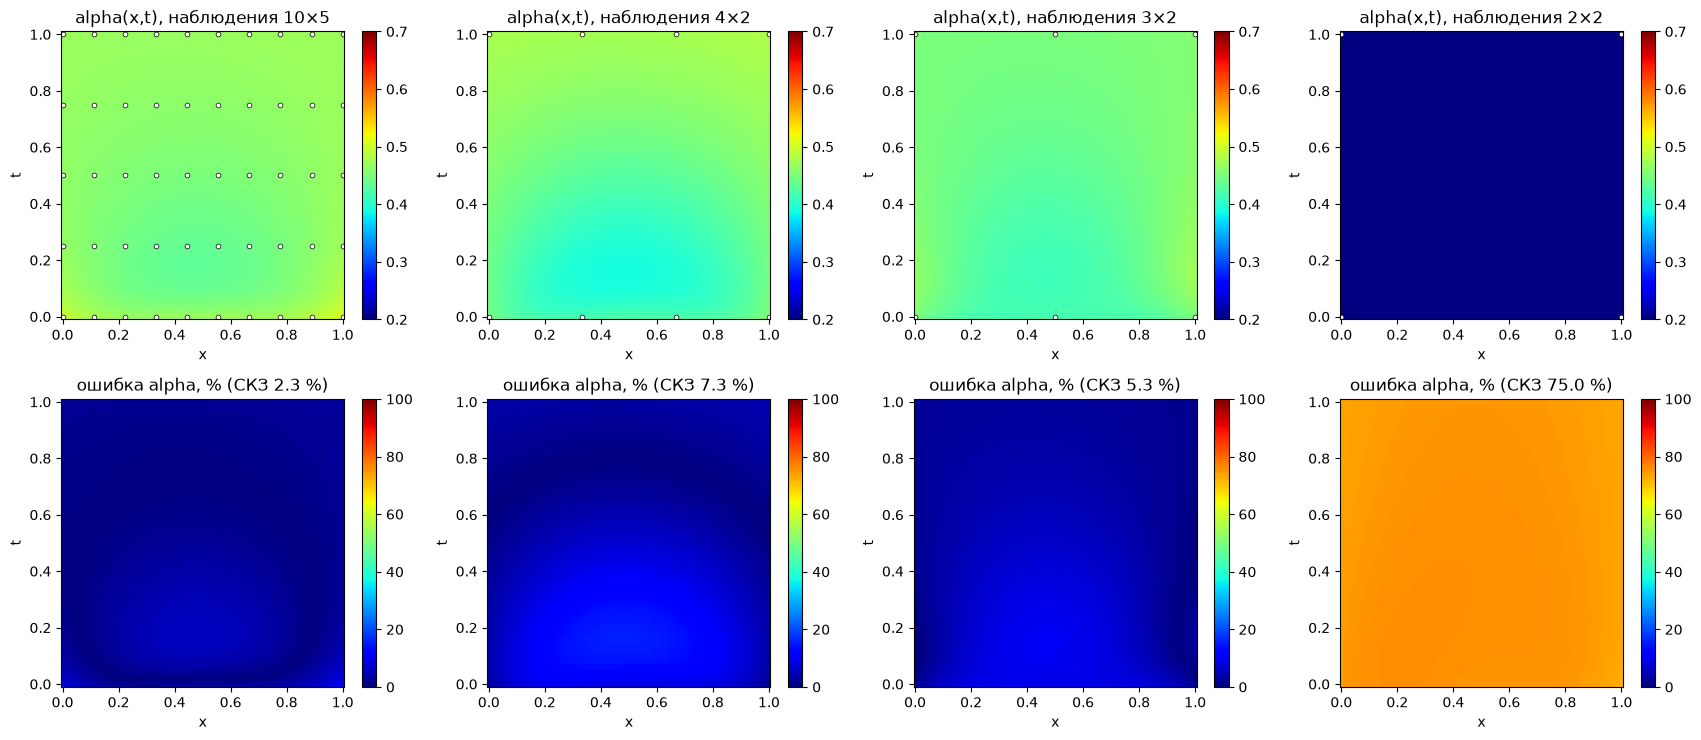

In [11]:
show = [(10, 5), (4, 2), (3, 2), (2, 2)]
fig, ax = plt.subplots(2, len(show), figsize=(4.3 * len(show), 7.5))
for k, key in enumerate(show):
    _, a_f = maps[key]
    ds = Dataset(Nx=key[0], Nt=key[1])
    pcm = ax[0, k].pcolormesh(X_EVAL, T_EVAL, a_f, shading="auto", cmap="jet", vmin=0.2, vmax=0.7)
    fig.colorbar(pcm, ax=ax[0, k])
    ax[0, k].scatter(ds.x, ds.t, c="w", s=12, edgecolors="k", lw=0.5)
    ax[0, k].set_title("alpha(x,t), наблюдения %d×%d" % key)
    pcm = ax[1, k].pcolormesh(X_EVAL, T_EVAL, np.abs(a_f - ALPHA_TRUE) / ALPHA_TRUE * 100,
                              shading="auto", cmap="jet", vmin=0, vmax=100)
    fig.colorbar(pcm, ax=ax[1, k])
    ax[1, k].set_title("ошибка alpha, %% (СКЗ %.1f %%)" % alpha_rms_error(a_f))
    for a_ in ax[:, k]:
        a_.set_xlabel("x"); a_.set_ylabel("t")
plt.tight_layout(); plt.show()

### Разные сиды

In [12]:
seed_grids = [(100, 50), (10, 5), (3, 2)]
print("%-8s %s" % ("сетка", "СКЗ alpha, % (сиды 0, 1, 2)"))
for key in seed_grids:
    errs = [alpha_rms_error(maps[key][1])]
    for seed in (1, 2):
        _, _, a_s = run_experiment(*key, PINN, seed=seed)
        errs.append(alpha_rms_error(a_s))
    print("%-8s %s   | среднее %.2f %%, разброс %.2f ... %.2f %%"
          % ("%dx%d" % key, "  ".join("%5.2f" % e for e in errs), np.mean(errs), min(errs), max(errs)))

сетка    СКЗ alpha, % (сиды 0, 1, 2)


100x50    3.23   1.51   1.13   | среднее 1.96 %, разброс 1.13 ... 3.23 %


10x5      2.34   1.20   2.58   | среднее 2.04 %, разброс 1.20 ... 2.58 %


3x2       5.30   9.02  12.29   | среднее 8.87 %, разброс 5.30 ... 12.29 %


## Выводы

- На сетке 100x50 α восстанавливается с СКЗ 1-3% (зависит от сида), ошибка u ~0.6%. Сеть сама получает почти постоянное α ≈ 0.46.
- По карте ошибка α больше всего в углах при t = 0 (там u = 0 и u_x мало, α почти не входит в уравнение), около x = 0.5 при малых t (там u_x = 0) и растёт к t = 1, где решение затухает до ~0.01.
- С α = const ошибка ~0.05%: у константы один параметр, а у поля α(x,t) много степеней свободы, и там, где u_x ≈ 0, оно плохо определяется.
- Разница между сетками от 100x50 до 10x5 (1-4%) меньше, чем разброс по сидам, поэтому график ошибки от числа точек получается неровным. Поэтому надо смотреть карту α, а не одно число.
- СКЗ ≤ 15% получается вплоть до сетки 3x2 (6 точек), на 2x2 не восстанавливается (75%). Точки на x = 0, x = 1 и t = 0 ничего не добавляют к ГУ/НУ, у 3x2 внутри области одна точка, у 2x2 ни одной. Стабильно (2-3% на любом сиде) работает сетка 10x5.